# MAGIC

In [1]:
import scipp as sc
import tof

import scippnexus as snx
from ess.reduce.unwrap import GenericUnwrapWorkflow
from ess.reduce.nexus.types import *
from ess.reduce.unwrap.types import *
from ess.reduce.unwrap.lut import LtotalRange, ChopperFrameSequence

## Chopper parameters

In [2]:
choppers = {
    "PSC1": {
        "frequency": {"value": 154.0, "unit": "Hz"},
        "open": {"value": [-94.3, -52.5], "unit": "deg"},
        "close": {"value": [-85.7, 52.5], "unit": "deg"},
        "distance": {"value": 6.229, "unit": "m"},
        "phase": {"value": 278.9295166835187, "unit": "deg"},
        "type": "chopper",
        "direction": "clockwise",
        "name": "PSC1",
    },
    "PSC2": {
        "frequency": {"value": 154.0, "unit": "Hz"},
        "open": {"value": [85.7, 307.5], "unit": "deg"},
        "close": {"value": [94.3, 412.5], "unit": "deg"},
        "distance": {"value": 6.244, "unit": "m"},
        "phase": {"value": 279.3078988877654, "unit": "deg"},
        "type": "chopper",
        "direction": "clockwise",
        "name": "PSC2",
    },
    "SC": {
        "frequency": {"value": 14.0, "unit": "Hz"},
        "open": {"value": [-10.3], "unit": "deg"},
        "close": {"value": [10.3], "unit": "deg"},
        "distance": {"value": 6.735, "unit": "m"},
        "phase": {"value": 32.04487360970678, "unit": "deg"},
        "type": "chopper",
        "direction": "clockwise",
        "name": "SC",
    },
    "BC": {
        "frequency": {"value": 14.0, "unit": "Hz"},
        "open": {"value": [-90.0], "unit": "deg"},
        "close": {"value": [90.0], "unit": "deg"},
        "distance": {"value": 79.9, "unit": "m"},
        "phase": {"value": 279.5287158746209, "unit": "deg"},
        "type": "chopper",
        "direction": "clockwise",
        "name": "BC",
    },
}

PSC1


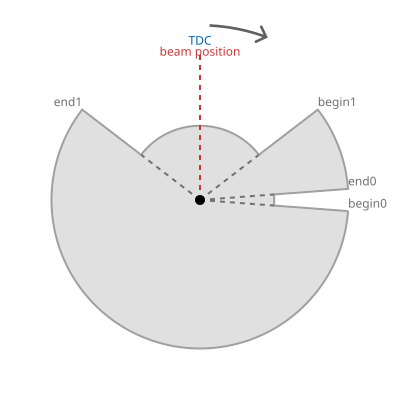

PSC2


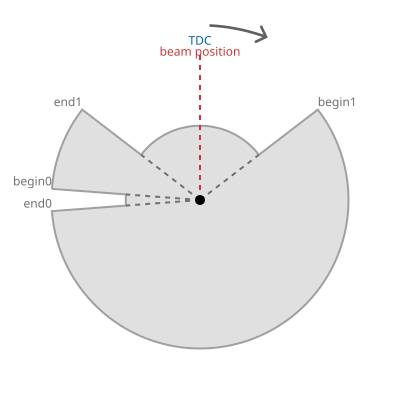

SC


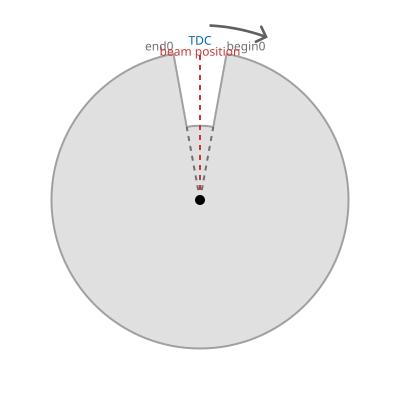

BC


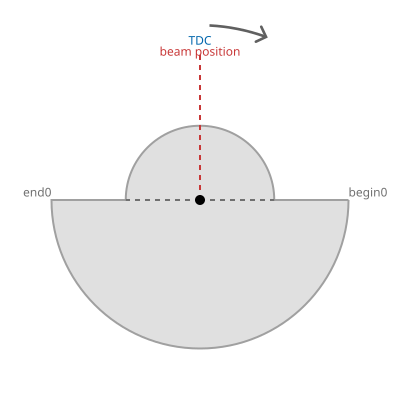

In [3]:
magic_choppers = {}
for key, ch in choppers.items():
    magic_choppers[key] = tof.Chopper.from_json(name=key, params=ch).to_diskchopper()

for key, ch in magic_choppers.items():
    print(key)
    display(ch)

## Tof model

Plot(ax=<Axes: xlabel='Time [μs]', ylabel='Distance [m]'>, fig=<Figure size 1200x480 with 2 Axes>)

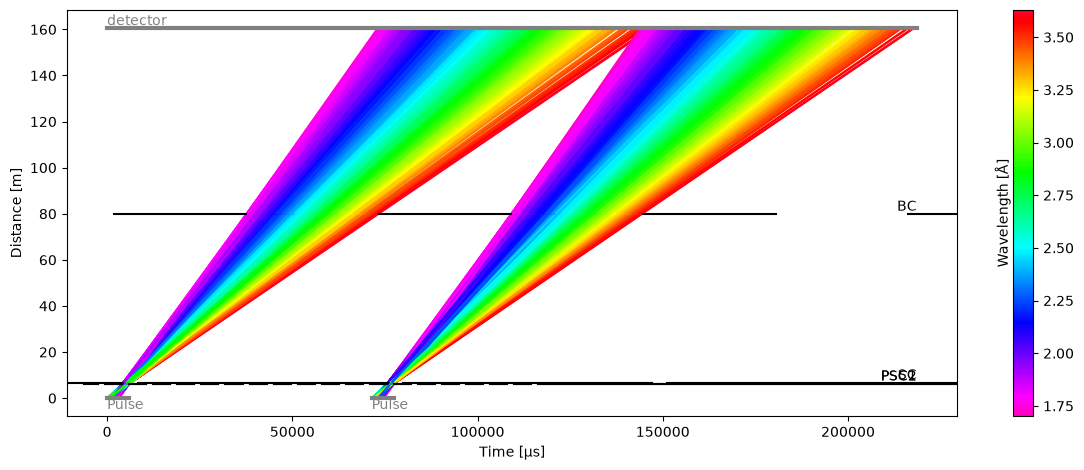

In [4]:
source = tof.Source(facility="ess", neutrons=1_000_000, pulses=2)
source_position = sc.vector([0, 0, 0], unit="m")
detector = tof.Detector(distance=sc.scalar(160.403, unit="m"), name="detector")

params = [
    tof.Chopper.from_diskchopper(ch, name=key) for key, ch in magic_choppers.items()
] + [detector]

model = tof.Model(source=source, components=params)
res = model.run()
res.plot()

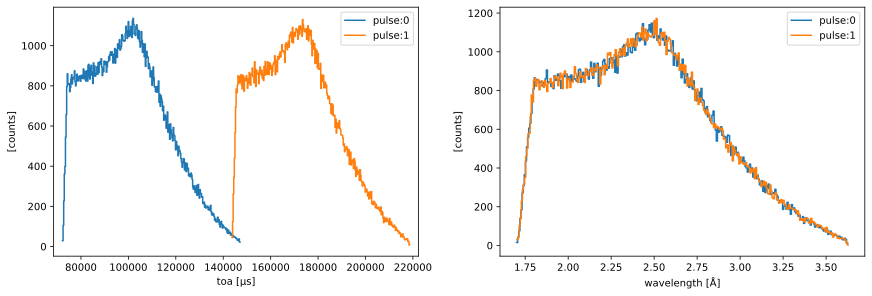

In [5]:
res["detector"].plot()

## Wavelength lookup table

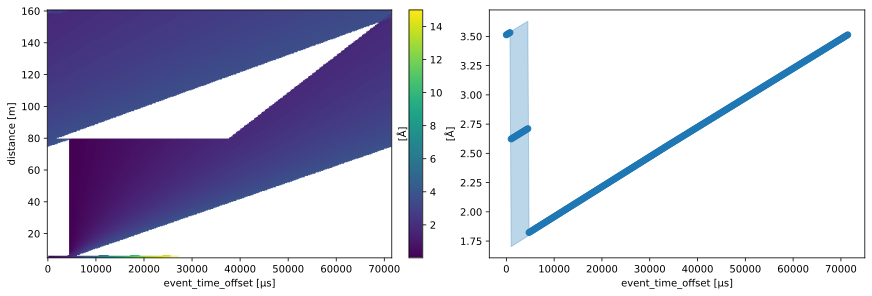

In [6]:
wf = GenericUnwrapWorkflow(
    run_types=[SampleRun], monitor_types=[], wavelength_from="analytical"
)

wf[DiskChoppers[SampleRun]] = magic_choppers
wf[LtotalRange[SampleRun, snx.NXdetector]] = sc.scalar(5, unit="m"), detector.distance
wf[Position[snx.NXsource, SampleRun]] = source_position

table = wf.compute(LookupTable[SampleRun, snx.NXdetector])
table.plot() + table.array['distance', -1].plot(errorbars='band')

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Frame propagation through chopper cascade'}, xlabel='ms', ylabel='Å'>)

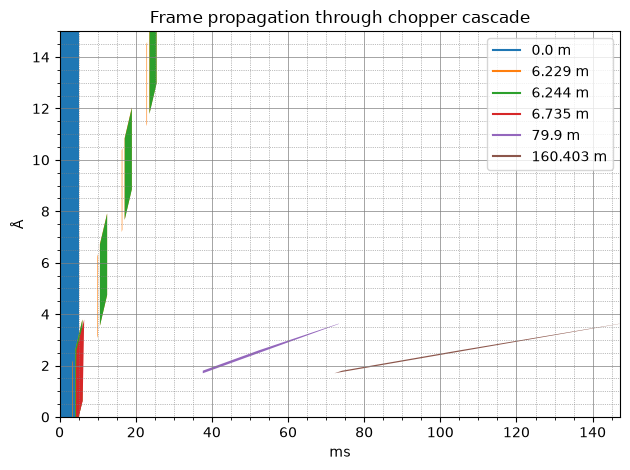

In [7]:
frames = wf.compute(ChopperFrameSequence[SampleRun])
at_sample = frames.propagate_to(detector.distance)
at_sample.draw()